<a href="https://colab.research.google.com/github/ghn9zh/DS3001-programming/blob/main/linear_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Linear Models
## Do three questions.
### `! git clone https://github.com/ds4e/linearModels`

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

1. A model is considered linear when it is linear in the parametner which means that the relationship between the target variable and the predictors is expressed as a sum of the parameters multiplied by the predictor variable. The key is that the model must not invole any multiplication, division, or exponentation of the parameter.

2. The coefficient for a dummy or one-hot-encoded variable represents the difference in the predicted value of the outcome variable between the category represented by that dummy and the reference catergory, assuming the model has an intercept. The intercept shows the baseline prediction for the reference catgory, and the dummy variable coefficient shows how muc hhigher or lower the prediction is for the other category.

3. Linear regression can be used for binary classficiation by predicting values between 0 and 1 and then applying the threshold. It is not ideal because the predictions are not constrained to just the 0-1 range and can produced numbers that don't make sense.

4. Signs of overfitting include very high accuracy on the training data but poor preformance on the validation or test data, sugesting the model is capturing noise rather than the underlying patterns. Other sings can include having overly complex models or too many predictors reative to the number of observations.

5. Multicollinearity occurs when two or more independent variables in a regression model are higly correlated with each other, making it difficult to estimate their individual effects accurately. This leads to unstable and unrealiable coefficient estimated. Two-stage least squares is on method to solve this issue. In the first stage, the problematic vairable is regressed on other variables that are not correlated with the error term to produce predicted values. In the second stage, these predicted values are used in the main regression model. This helps isolate the true effect of variable by removing the multicollinearity.

6. Nonlinear relationships can be incoroporated into a linear model by transforming the independent vairables. A way to do this is adding sqaured or cubed variables, applying functions like logs or exponentials, or including interaction terms between variables. These transformations allow the model to capture curves or more complex relationships while still remaining linear in the parameters.

7. An intercept is the expected value of the outcome variable when all predictors are equal to zero. It may or may not be meaningful depending on your context. A slope coefficient for a variable is the expected change in the outcome variable for a one-unit increase in that predictor, holding all other variables constant. A coefficient for a dummy/one-hot-encoded variable is the expected difference in the outcome between the category represented by the dummy and the refrence category.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1]:
! git clone https://github.com/ds4e/linearModels

Cloning into 'linearModels'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 43 (delta 5), reused 4 (delta 4), pack-reused 33 (from 1)
Receiving objects: 100% (43/43), 4.12 MiB | 13.76 MiB/s, done.
Resolving deltas: 100% (8/8), done.


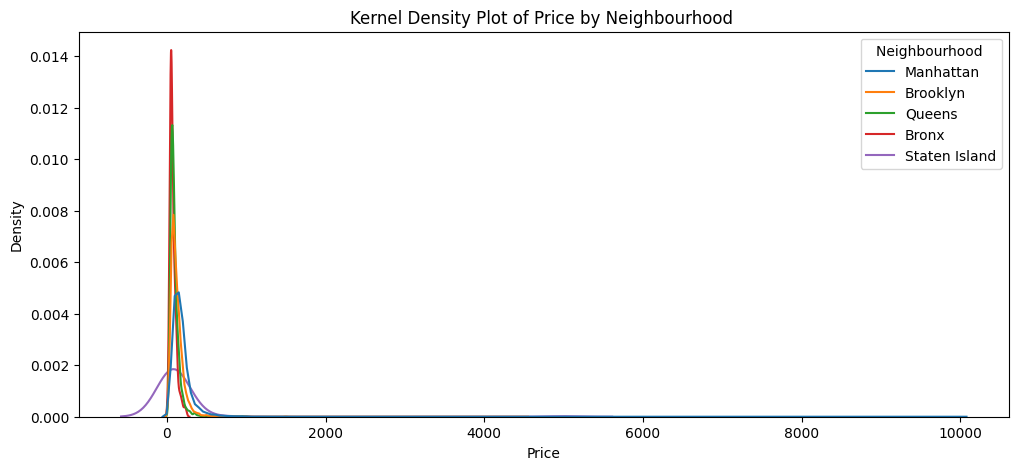

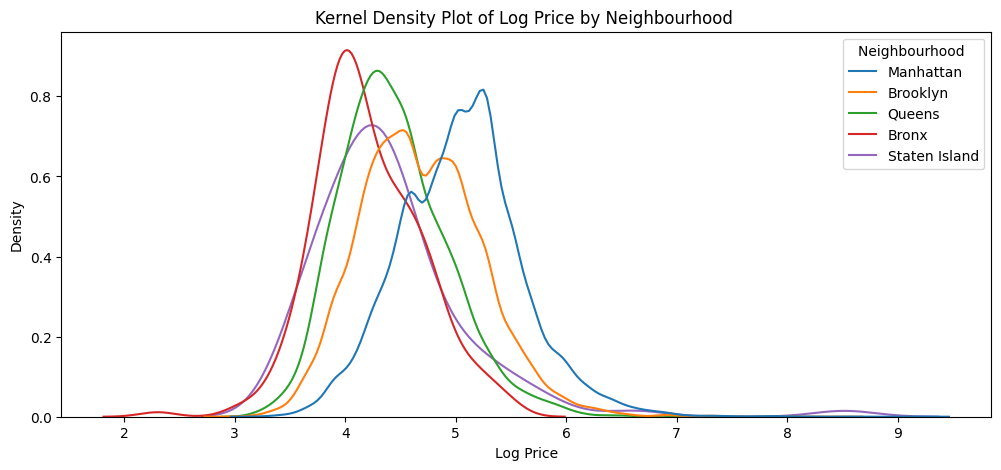

In [11]:
#Question 2.1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

data= pd.read_csv('/content/linearModels/assignment/data/Q1_clean.csv')

#Summary Table for Neighbourhood Price
grouped_stats = (
    data.groupby("Neighbourhood ")[["Price", "Review Scores Rating"]]
    .mean()
    .sort_values(by="Price", ascending=False)
)
grouped_stats
#Manhattan is most expensive on avg

# Add a column for log-transformed price
data["Log Price"] = np.log(data["Price"])

# Plot kernel density for Price grouped by Neighbourhood
plt.figure(figsize=(12, 5))
sns.kdeplot(data=data, x="Price", hue="Neighbourhood ", common_norm=False)
plt.title("Kernel Density Plot of Price by Neighbourhood ")
plt.xlabel("Price")
plt.show()

# Plot kernel density for Log Price grouped by Neighbourhood
plt.figure(figsize=(12, 5))
sns.kdeplot(data=data, x="Log Price", hue="Neighbourhood ", common_norm=False)
plt.title("Kernel Density Plot of Log Price by Neighbourhood ")
plt.xlabel("Log Price")
plt.show()

In [16]:
#Question 2.2
from sklearn.linear_model import LinearRegression

X2 = pd.get_dummies(data["Neighbourhood "], drop_first=False)
y2 = data["Price"]
model2 = LinearRegression(fit_intercept=False)
model2.fit(X2, y2)
coeffs2 = pd.Series(model2.coef_, index=X2.columns)
print(coeffs2)

#The values match exactly with the averages from the question above.
#When regressing a continuous variable on a categorical variable without an
#intercept, each coefficient is the mean of the group.

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


In [18]:
#Question 2.3

X3 = pd.get_dummies(data["Neighbourhood "], drop_first=True)
model3 = LinearRegression()
model3.fit(X3, y2)
coeffs3 = pd.Series(model3.coef_, index=X3.columns)
intercept3 = model3.intercept_

print(coeffs3)
print(intercept3)

#When including an intercept you must drop one dummy to avoid multicollinearity
#The dropped category becomes the refrence group

#The intercept is the average price for the refrence group which is the bronx (75.28)

#Each coefficient represents how much more of less expensive that brough is
#compared to the Bronx.

#To get the coeffs in part to from the news coeffs you just add the intercpet to
#each coeff from the model with the intercept.

Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64
75.27649769585331


In [25]:
#Question 2.4

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import pandas as pd

# Create dummy variables for Neighbourhood
X = data[["Review Scores Rating"]].join(pd.get_dummies(data["Neighbourhood "], drop_first=True))
y = data["Price"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)
print("Coefficient on Review Scores Rating:", model.coef_[0])

#R^2 on test set is 0.030. RMSE is $205.54. Coeff on Review Score Rating is +1.05.
#Can't account for most exspensive property type with this model

R²: 0.029998487885614766
RMSE: 205.5375766164578
Coefficient on Review Scores Rating: 1.0517877696820435


In [28]:
#2.5

X = data[["Review Scores Rating"]].join(
    pd.get_dummies(data["Neighbourhood "], drop_first=True)
).join(
    pd.get_dummies(data["Property Type"], drop_first=True)
)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("RMSE:", rmse)
print("Coefficient on Review Scores Rating:", model.coef_[0])

#R^2 on test set is 0.038. RMSE is $204.67. Coeff on Review Score Rating is +1.05.

#most expensive property type
property_cols = pd.get_dummies(data["Property Type"], drop_first=True).columns
property_coeffs = pd.Series(model.coef_[-len(property_cols):], index=property_cols)
most_expensive_property = property_coeffs.idxmax()
print(most_expensive_property)

#Most exspensive property type is a townhouse

R²: 0.03813988400894919
RMSE: 204.6732022676915
Coefficient on Review Scores Rating: 1.0493652221871215
Townhouse


Question 2.6:

When property type is added in part 5, the coeff on review scores rating decreases slightly. This means that some effect previously attributed to review scores is now being explained by difference in property type instea. In multiple linear repression, coeffs adjust based on other variables included in the model. The change reflect a more accurate estimate of the effect or review score rating on price.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [6]:
#Question 3.1

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('/content/linearModels/assignment/data/cars_hw.csv')
data.drop(columns=['Unnamed: 0'], inplace=True)


# Standardize numerical features
scaler = StandardScaler()
data[['Make_Year_scaled', 'Seating_Capacity_scaled']] = scaler.fit_transform(
    data[['Make_Year', 'Seating_Capacity']]
)

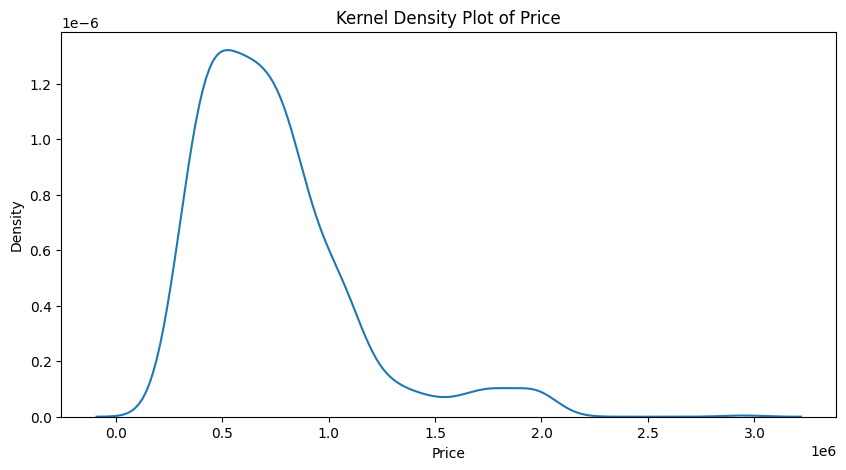

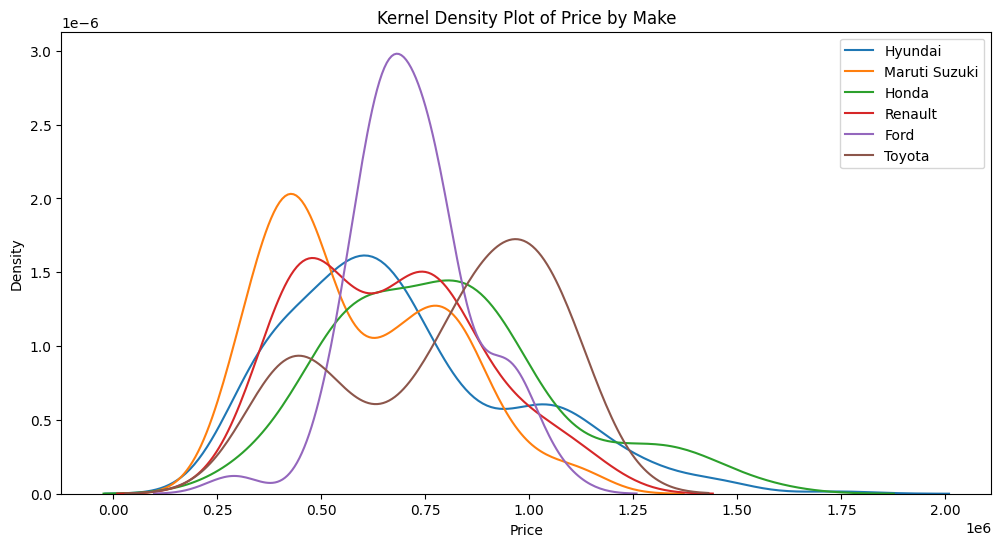

In [9]:
#Question 3.2

import seaborn as sns
import matplotlib.pyplot as plt

# Summary
price_summary = data['Price'].describe()
price_by_make = data.groupby('Make')['Price'].describe().sort_values(by='mean', ascending=False)

# KDE plot of price
plt.figure(figsize=(10, 5))
sns.kdeplot(data['Price'].values)
plt.title('Kernel Density Plot of Price')
plt.xlabel('Price')
plt.show()

# KDE by Make
top_makes = data['Make'].value_counts().nlargest(6).index
plt.figure(figsize=(12, 6))
for make in top_makes:
    sns.kdeplot(data[data['Make'] == make]['Price'].values, label=make)
plt.title('Kernel Density Plot of Price by Make')
plt.xlabel('Price')
plt.legend()
plt.show()

#The most expesive car brands are honda and hyundai
#In general prices are right-skewed which means most cars are priced on lower end
#There are a view expensive outliers that pull price up

In [11]:
#Question 3.3

from sklearn.model_selection import train_test_split

# Define target
X = data.copy()
y = X['Price']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
#Question 3.4

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np

#Numeric only model
numeric_features = ['Mileage_Run', 'Make_Year_scaled', 'Seating_Capacity_scaled']
X_train_num = X_train[numeric_features]
X_test_num = X_test[numeric_features]

model_num = LinearRegression()
model_num.fit(X_train_num, y_train)
test_preds_num = model_num.predict(X_test_num)
r2_test_num = r2_score(y_test, test_preds_num)
rmse_test_num = np.sqrt(mean_squared_error(y_test, test_preds_num))

# categorical only model
categorical_cols = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'No_of_Owners']
X_train_cat = pd.get_dummies(X_train[categorical_cols], drop_first=True)
X_test_cat = pd.get_dummies(X_test[categorical_cols], drop_first=True)

# Align columns (in case some are missing from test set)
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join='left', axis=1, fill_value=0)

model_cat = LinearRegression()
model_cat.fit(X_train_cat, y_train)
test_preds_cat = model_cat.predict(X_test_cat)
r2_test_cat = r2_score(y_test, test_preds_cat)
rmse_test_cat = np.sqrt(mean_squared_error(y_test, test_preds_cat))

# combined model
X_train_combined = pd.concat([X_train_num.reset_index(drop=True), X_train_cat.reset_index(drop=True)], axis=1)
X_test_combined = pd.concat([X_test_num.reset_index(drop=True), X_test_cat.reset_index(drop=True)], axis=1)

model_combined = LinearRegression()
model_combined.fit(X_train_combined, y_train)
test_preds_combined = model_combined.predict(X_test_combined)
r2_test_combined = r2_score(y_test, test_preds_combined)
rmse_test_combined = np.sqrt(mean_squared_error(y_test, test_preds_combined))

# results printed

print(f"Numeric-only Model     → R²: {r2_test_num:.3f}, RMSE: {rmse_test_num:.3f}")
print(f"Categorical-only Model → R²: {r2_test_cat:.3f}, RMSE: {rmse_test_cat:.3f}")
print(f"Combined Model         → R²: {r2_test_combined:.3f}, RMSE: {rmse_test_combined:.3f}")

#The categorical-only preformed better on the test set than the numerical-only.
#The lower RSME of cat-only shows more accurate preictions and the higher R2 explains more variance.

#The combined model preforms better than both of the singular ones.
#The RSME decreases alot from the numerican and a little bit fro mthe caterogical which shows
#more accuracy overall. The R2 increase a lot over the numerical and a little over the catergorical
#which explains more vairnace than both the other mdoels. Overall the combined model improves prediction.


Numeric-only Model     → R²: 0.294, RMSE: 284546.952
Categorical-only Model → R²: 0.709, RMSE: 182791.106
Combined Model         → R²: 0.820, RMSE: 143575.197


In [24]:
#Question 3.5

from sklearn.preprocessing import PolynomialFeatures

#store results for plotting and comparison
results = []

# Try degrees 1 through 5
for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_num)
    X_test_poly = poly.transform(X_test_num)

    model_poly = LinearRegression()
    model_poly.fit(X_train_poly, y_train)

    test_preds_poly = model_poly.predict(X_test_poly)
    r2_poly = r2_score(y_test, test_preds_poly)
    rmse_poly = np.sqrt(mean_squared_error(y_test, test_preds_poly))

    results.append({
        'degree': degree,
        'r2_test': r2_poly,
        'rmse_test': rmse_poly
    })

# Display results
results_df = pd.DataFrame(results)
print("Polynomial Regression Results on Test Set:")
print(results_df)

# Find the best performing model
best_model = results_df.loc[results_df['r2_test'].idxmax()]
print("\n Best Degree:", int(best_model['degree']))
print(f"R²: {best_model['r2_test']:.3f}, RMSE: {best_model['rmse_test']:.3f}")



#R² does not become negative at degree 1-5
#combined linear model from Part 4 performs better than the best polynomial model.
# R² is nearly double inthe combined model and RMSE is significantly lower in the combined model.


Polynomial Regression Results on Test Set:
   degree   r2_test      rmse_test
0       1  0.294070  284546.951907
1       2  0.326911  277849.355199
2       3  0.321880  278885.735518
3       4  0.262012  290936.266686
4       5  0.202674  302406.540021

 Best Degree: 2
R²: 0.327, RMSE: 277849.355


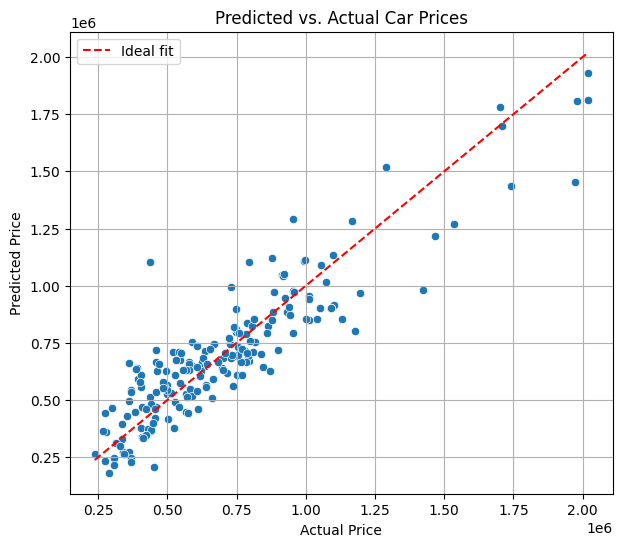

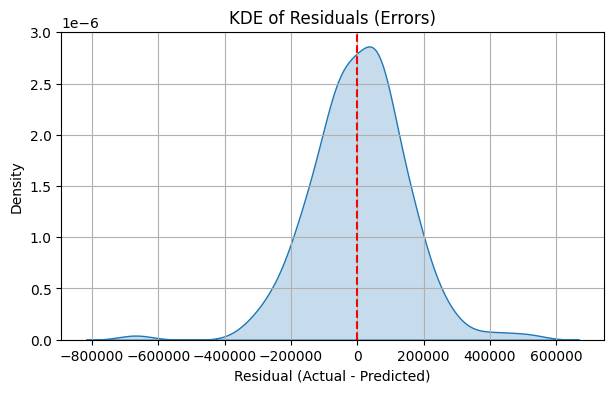

Residuals Summary:
count       196.000000
mean       5204.919938
std      143848.249711
min     -667978.462793
25%      -79207.953879
50%        7228.414416
75%       81299.767788
max      518526.831791
Name: Price, dtype: float64


In [25]:
#Question 3.6

import matplotlib.pyplot as plt
import seaborn as sns

# Use the best model: combined model trained earlier
y_test_actual = X_test['Price']
y_test_pred = model_combined.predict(X_test_combined)

# 1. Scatter plot: Predicted vs Actual
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test_actual, y=y_test_pred)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         color='red', linestyle='--', label='Ideal fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Predicted vs. Actual Car Prices')
plt.legend()
plt.grid(True)
plt.show()

#tThe predicted values and true values do roughly line up along the diagonal

# 2. Residuals
residuals = y_test_actual - y_test_pred

# 3. KDE of residuals
plt.figure(figsize=(7, 4))
sns.kdeplot(residuals, fill=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('KDE of Residuals (Errors)')
plt.xlabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.show()

#The residuals do look roughly bell-shaped around zero

# 4. Basic stats
print("Residuals Summary:")
print(residuals.describe())

#Strengths: The combined model captures a large proportion of variance in car prices (R² ≈ 0.81)
# and generalizes well, as seen by strong performance on the test set.

#Weaknesses: Residuals show some spread and possible non-linearity, indicating the model
#may miss complex interactions or patterns not captured by linear relationships alone.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group who do not receive a transplant, and (b) the difference between the proportion of people who survive in the treatment group and the proportion of people who survive in the control group. In a randomized controlled trial, this is called the **average treatment effect**.
2. Regress `y` on `transplant` using a linear model with a constant. How does the constant/intercept of the regression and the coefficient on transplant compare to your answers from part 1? Explain the relationship clearly.
3. We'd like to include `age` in the regression, since it's reasonable to expect that older patients are less likely to survive an extensive surgery like a heart transplant. Regress `y` on a constant, transplant, and age. How does the intercept change?
4. Build a more flexible model that allows for non-linear age effects and interactions between age and treatment. Use a train-test split to validate your model. Estimate your best model, predict the survival probability by age, and plot your results conditional on receiving a transplant and not. Describe what you see.
5. Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?

**Q5.** This is a question about linear regression. The outcome is whether a defendant is held pre-trial in the Virginia justice system. We would like to understand how that outcome is predicted by characteristics of the defendant, particularly race. Let's be very careful/clear: We aren't saying anyone *should* be held without bond or asserting that people with different demographic variables *should* be more likely to be held, but instead trying to predict whether people with different characteristics *are empirically more likely* to be held without bond, given the available information. This is the first step we would take in investigating whether a system is fair, or how large the disparities are: Does it treat people with similar observable characteristics similarly, or not? We are going to look at a common question: Are Black defendants treated differently from white or Asian ones? (There are Native American defendants, but there are 11 in total, which is such a small number of observations that is difficult to clearly say anything about how this group is treated relative to the others.)

The variables in the data are:

  - `held_wo_bail`: Whether a defendant is held without bail before trial (Boolean logical)
  - `race`, `sex`: Categorical demographic variables
  - `is_poor`: Whether the defendant is classified as indigent
  - `prior_F`, `prior_M`: The number of prior felony and misdemeanor arrests
  - `case_type`: A categorical variable indicating a misdemeanor `M` or felony `F` or infraction `I` or special case `S`
  - `age`: Defendant's age
  - `bond`, `bond_NA`, `bond_type`: The amount of any bond, whether it is missing, and the type
  - `sentence`, `sentence_NA`, `sentence_type`: The length of any sentence, whether it is missing, and the type

1. Load the `pretrial_data.csv` data. Notice that there are `nan`s, but the data are relatively clean. Because there are `.nan`s among variables you won't use, you'll want to narrow down your analysis to the relevant variables before dropping or imputing missing values.
2. Create a dummy variable indicating that the defendant is Black.
3. Regress `held` on `Black`. What is the slope coefficient Interpret the coefficient on the Black dummy variable: How much more likely is a black person to be held without bail? What is the $R^2$ of the model?
4. Before doing this question, please think for a few minutes about how to make the process of running the following regressions as efficient as possible, before jumping into writing code. Repeat part 2, for the following specifications, keeping track of the coefficient on the Black dummy variable each time:
      - `held` on `Black` and `sex`
      - `held` on `Black` and `sex` and `is_poor`
      - `held` on `Black` and `sex` and `is_poor` and `prior_F`
      - `held` on `Black` and `sex` and `is_poor` and `prior_F` and `case_type`
What happens to the coefficient on the Black dummy variable as you include more regressors/features/controls in the regression? Explain your findings.
5. Suppose we don't want to see just `Black` and `sex`, but `Black` interacted with `sex`: Are Black men and Black women treated systemically differently from the rest of the population? Implement this in a regression, and explain your findings.
6. Imagine someone argued we should use these kinds of models to help a judge or magistrate make bail decisions (you could obviously go back and make this kind of model for the bond and sentence variables, then deploy it on new cases to predict what their bond and sentence values would be). What concerns would you have? Do you think society should be using data-driven and automated tools like that? Explain your concerns clearly.

**Q6.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

**Q7.** In class, we showed that for the single linear regression model,
\begin{alignat*}{3}
a^* &=& \bar{y} \\
b^* &=& \dfrac{\sum_{i=1}^N(y_i - \bar{y})(x_i-\bar{x})}{\sum_{i=1}^N (x_i-\bar{x})^2},
\end{alignat*}

1. When will $b^*$ be large or small, depending on the relationship between $X$ and $Y$ and the variance of $X$?
2. Suppose you have measurement error in $X$ which artificially inflates its variance (e.g. bad data cleaning). We'll model this as saying the "real" value of $X$ for observation $i$ is $z_i$, but we observe $x_i = z_i + n_i$, where $n_i$ is the added noise. Does this affect the intercept of the regression? What happens to the $b^*$ coefficient relative to a noise-less model? How will affect your ability to predict? (This phenomenon is called **attenuation**.)
3. Suppose the noise $n_i$ is independent of $z_i$ and $y_i$, so that (approximately)
$$
\dfrac{1}{N} \sum_{i=1}^N (y_i - \bar{y})(n_i - \bar{n}) =0, \quad \dfrac{1}{N} \sum_{i=1}^N (z_i - \bar{z})(n_i - \bar{n}) =0.
$$
and that the mean of the bias is zero, so that
$$
\dfrac{1}{N} \sum_{i=1}^N n_i = 0.
$$
In this case, the noise $n_i$ is zero on average and independent of the values of $x_i$ and $y_i$: It's just measurement error or lazy data cleaning.
Explain the intuition of your result.

4. How does attenuation factor into the cost-benefit analysis of gathering higher quality data or cleaning it more carefully?

**Q8.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the SSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

**Q9.** There is a folder called `heart_failure` which contains reasonably detailed health data on patients and whether they die of congestive heart failure.

1. Load the data and perform an 80/20-train/test split.
2. Using dummy/one-hot-encoded variables and transformations of the numeric features, build the best model you can. **But**, do not delete code chunks or revise your work substantially as you experiment. Just keep moving forward with your ideas and experiments.
3. When you're done, scroll through your notebook. What worked and what didn't? Does your code have intention, or are you randomly experimenting? If you had to do this again, what might you do differently to get to a good model faster?


**Q10.** Let's look at a cousin of Linear Regression, called **kernel regression** or **local constant least squares** or **Nadaraya-Watson Estimator**.

We derived the OLS estimator for single linear regression by minimizing
$$
SSE(b_0, b_1) = \frac{1}{N}\sum_{i=1}^N (y_i - b_0 - b_1 x_i)^2
$$
with solution
$$
\hat{b}_0 = \bar{y} - \hat{b}_1 \bar{x}, \quad \hat{b}_1 = \dfrac{\frac{1}{N} \sum_{i=1}^N (x_i-\bar{x})(y_i - \bar{y})}{s_x^2}.
$$

When you step back and think about it, this is a bit weird: The algorithm is computing sample means, variances, and covariances, and using those to create a predictive model. The data themselves arguably vanish from the solution. This is elegant, this is strange.

Instead, let $k(z)$ be a kernel function, such as the Gaussian
$$
k(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}
$$
or uniform
$$
k(z) = \begin{cases}
1/2, & |z| \le \frac{1}{2}\\
0, & \text{otherwise.}
\end{cases}
$$
We'll instead minimize, or each predictor value $x$,
$$
SSE(\hat{y}(x)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(x)\right\rbrace^2 \dfrac{1}{h} k \left( \dfrac{x-x_i}{h} \right).
$$

1. Show that the optimal predictor is
$$
\hat{y}(x) = \dfrac{ \frac{1}{Nh} \sum_{i=1}^N  y_i k \left( \dfrac{x-x_i}{h} \right) }{\frac{1}{Nh} \sum_{i=1}^N k \left(  \dfrac{x-x_i}{h} \right)}
$$
This has many names, but let's call it the local constant least squares (LCLS) estimator, as opposed to ordinary least squares (OLS).

2. Compare and contrast LCLS with both OLS and $k$-Nearest Neighbor as a regression algorithm.

3. Write a function or class that implements the LCLS estimator for a single predictor variable $x$. For a default bandwidth $h$, you can use the maximum of the Silverman plug-ins for estimating kernel densities for $X$ and $Y$:
$$
h_y = 1.06 \times s_y^{-1/5}, \quad h_x = 1.06 \times s_x^{-1/5},
$$
$$
h = \max \{ h_y, h_x \}.
$$
For the kernel, you can hard-code the uniform, Gaussian, or Epanechnikov, or make it a parameter the user can adjust with a default choice.

4. For one of the datasets available for the homework, use your LCLS estimator from part 3 to predict values $\hat{y}(x_i)$ for each datapoint $x_i$. Plot your estimator $\hat{y}$ as a line over a scatterplot of the data $\{(x_i,y_i)\}_{i=1}^N$. Tune the bandwidth until you

5. Conceptually, how would you extend this analysis to a vector of predictors, $x = (x_1, ..., x_L)$ instead of just one explanatory variable $x$?
